In [46]:
# Defining project paths
BASE_DIR = "D:/Capstone/capstone_repo"
DATA_DIR = f"{BASE_DIR}/data/raw"
OUTPUT_DIR = "C:/Users/afafb/OneDrive/Desktop/Marrakech Data"
COLLECTION_OUTPUT_DIR = f"{BASE_DIR}/data/collection_output"
import os
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(COLLECTION_OUTPUT_DIR, exist_ok=True)

In [72]:
import osmnx as ox
import networkx as nx
import geopandas as gpd
import pandas as pd
from shapely import wkt
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterstats import zonal_stats
from rasterio.mask import mask
from rasterio.transform import xy

# DISTRICTS

In [48]:
# Load administrative boundaries for Casablanca: data downloaded from GADM
districts = gpd.read_file(f"{DATA_DIR}/gadm/gadm41_MAR_4.shp") 

In [49]:
districts['NAME_2'].value_counts()

NAME_2
Taroudannt               89
Settat                   71
El Kelaâ des Sraghna     67
Ouarzazate               59
Essaouira                57
El Jadida                52
Taza                     49
Taounate                 49
Errachidia               47
Nador                    46
Azilal                   44
Tiznit                   44
Sidi Kacem               40
Al Haouz                 39
Béni Mellal              38
Khénifra                 38
Safi                     37
Chichaoua                35
Khémisset                35
Al Hoceïma               35
Casablanca               34
Chefchaouen              34
Kénitra                  33
Tétouan                  31
Khouribga                31
Meknès                   25
Berkane Taourirt         25
Sefrou                   23
Chtouka-Aït Baha         22
Boulemane                21
Tata                     20
Guelmim                  20
Larache                  19
Jerada                   19
Ben Slimane              19
Marrakech    

In [50]:
# Filter to only include districts that contain "Marrakech"
marrakech_districts = districts[districts['NAME_2'].str.contains("Marrakech", case=False, na=False)]

In [51]:
marrakech_districts.head()

,GID_4,GID_0,COUNTRY,GID_1,NAME_1,GID_2,NAME_2,GID_3,NAME_3,NAME_4,VARNAME_4,TYPE_4,ENGTYPE_4,CC_4,geometry
634,MAR.8.5.1.1_1,MAR,Morocco,MAR.8_1,Marrakech - Tensift - Al Haouz,MAR.8.5_1,Marrakech,MAR.8.5.1_1,Bour,Alouidane,NA,Commune Rural,Rural Commune,NA,"POLYGON ((-7.72595 31.57572, -7.72638 31.57503..."
635,MAR.8.5.1.2_1,MAR,Morocco,MAR.8_1,Marrakech - Tensift - Al Haouz,MAR.8.5_1,Marrakech,MAR.8.5.1_1,Bour,Harbil,NA,Commune Rural,Rural Commune,NA,"POLYGON ((-8.03933 31.88142, -8.02949 31.86541..."
636,MAR.8.5.1.3_1,MAR,Morocco,MAR.8_1,Marrakech - Tensift - Al Haouz,MAR.8.5_1,Marrakech,MAR.8.5.1_1,Bour,M'Nabha,NA,Commune Rural,Rural Commune,NA,"POLYGON ((-8.19203 32.06273, -8.18972 32.05997..."
637,MAR.8.5.1.4_1,MAR,Morocco,MAR.8_1,Marrakech - Tensift - Al Haouz,MAR.8.5_1,Marrakech,MAR.8.5.1_1,Bour,Ouahat Sidi Brahim,NA,Commune Rural,Rural Commune,NA,"POLYGON ((-7.90825 31.72635, -7.89882 31.72384..."
638,MAR.8.5.1.5_1,MAR,Morocco,MAR.8_1,Marrakech - Tensift - Al Haouz,MAR.8.5_1,Marrakech,MAR.8.5.1_1,Bour,Oulad Dlim,NA,Commune Rural,Rural Commune,NA,"POLYGON ((-8.32949 31.94591, -8.32753 31.94941..."


In [52]:
marrakech_districts = marrakech_districts.to_crs(epsg=4326)

In [53]:
# Check unique district names to understand the structure of the data
marrakech_districts["NAME_3"].unique()

array(['Bour', 'Loudaya', 'NA (Annakhil)', 'NA (Machouar Kasba)',
       'NA (Marrakech Medina)', 'NA (Menara Gueliz)',
       'NA (Sidi Youssef Ben Ali)'], dtype=object)

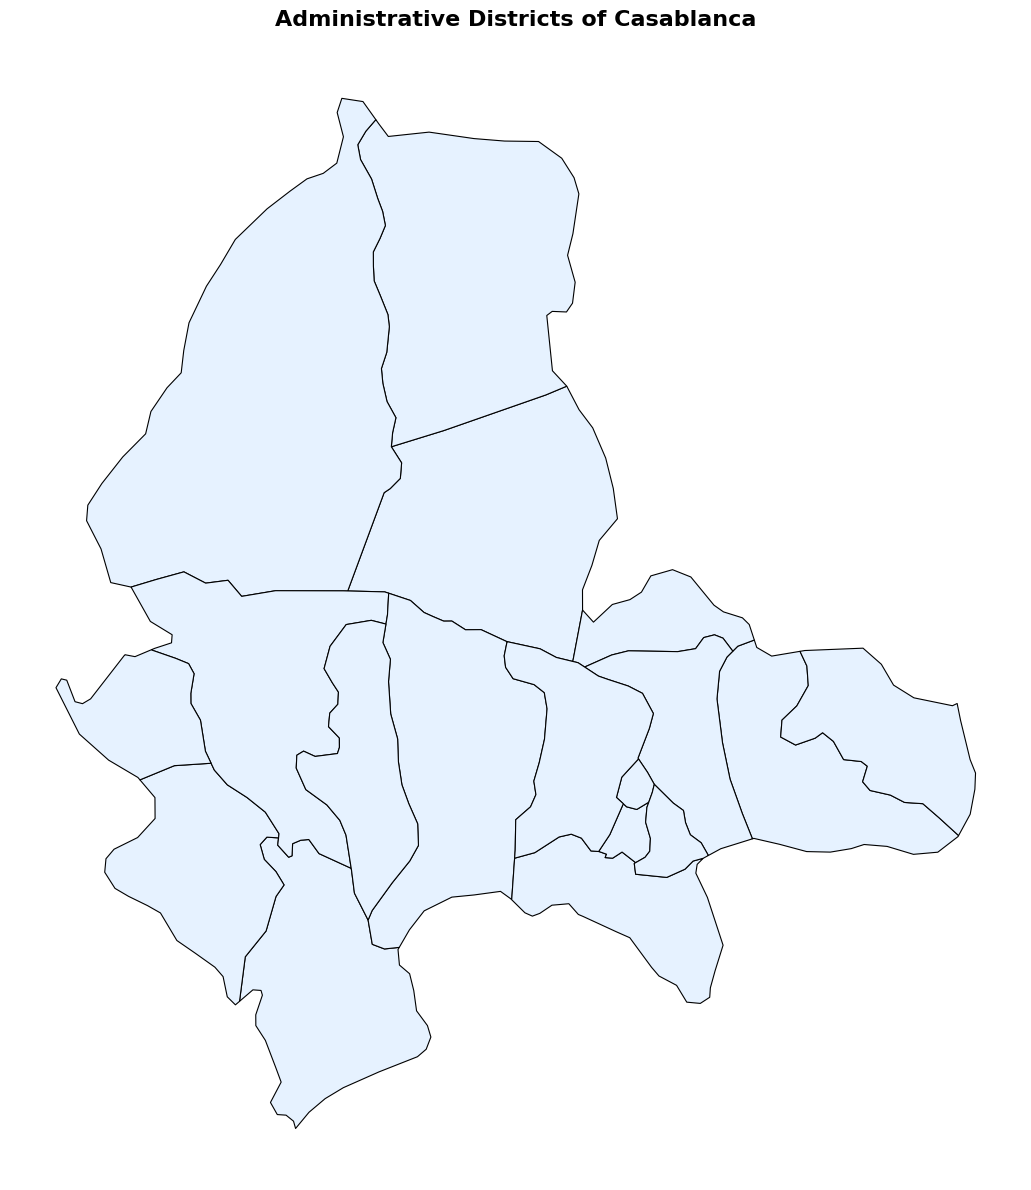

In [54]:
# Plotting the districts
fig, ax = plt.subplots(figsize=(12, 12))

# Plot districts
marrakech_districts.plot(
    ax=ax,
    edgecolor='black',
    facecolor='#e6f2ff',  # softer blue
    linewidth=0.8
)

# Title
ax.set_title(
    "Administrative Districts of Casablanca",
    fontsize=16,
    fontweight='bold',
    pad=15
)

# Remove axes for clean map
ax.set_axis_off()

# Tight layout
plt.tight_layout()

# Save 
plt.savefig(
    f'{COLLECTION_OUTPUT_DIR}/CasablancaDistricts.png',
    dpi=300, 
    bbox_inches='tight'
)

plt.show()

### Basic data inspection

In [55]:
print("Districts dataset:", marrakech_districts.shape)

Districts dataset: (18, 15)


In [56]:
marrakech_districts.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 18 entries, 634 to 651
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   GID_4      18 non-null     object  
 1   GID_0      18 non-null     object  
 2   COUNTRY    18 non-null     object  
 3   GID_1      18 non-null     object  
 4   NAME_1     18 non-null     object  
 5   GID_2      18 non-null     object  
 6   NAME_2     18 non-null     object  
 7   GID_3      18 non-null     object  
 8   NAME_3     18 non-null     object  
 9   NAME_4     18 non-null     object  
 10  VARNAME_4  18 non-null     object  
 11  TYPE_4     18 non-null     object  
 12  ENGTYPE_4  18 non-null     object  
 13  CC_4       18 non-null     object  
 14  geometry   18 non-null     geometry
dtypes: geometry(1), object(14)
memory usage: 2.2+ KB


The datatset contains 34 administrative units with 15 columns, including hierarchical identifiers (GID_0 to GID_4), names at different levels, and geometry. All fields are complete except `VARNAME_4` and `CC_4`, which are empty.

### Dropping Columns
Dropping empty columns                                                            
Others are not necessary for the scope of this project

In [57]:
to_drop = ["GID_4", "GID_0", "COUNTRY", "GID_1", "NAME_1", "GID_2", "NAME_2", "GID_3", "VARNAME_4", "TYPE_4", "CC_4"]
marrakech_districts = marrakech_districts.drop(columns=to_drop)

### Renaming Columns

In [58]:
marrakech_districts.rename(columns={"NAME_3": "district",
                           "NAME_4": "commune",
                           "ENGTYPE_4": "commune_type"
                          }, inplace=True)

### Cleaning the commune type by keeping only type

In [59]:
# Removing " Commune" suffix from commune_type for better readability
marrakech_districts['commune_type'] = marrakech_districts['commune_type'].str.replace(' Commune', '', regex=False)

In [60]:
marrakech_districts['commune_type'].value_counts()

commune_type
Rural    13
Urban     5
Name: count, dtype: int64

In [61]:
# Encoding commune types as ordinal values: Urban = 1, Rural = 0
marrakech_districts['commune_type_encoded'] = marrakech_districts['commune_type'].map({'Urban': 1, 'Rural': 0})

# Dropping commune_type column
marrakech_districts = marrakech_districts.drop(columns=["commune_type"])

### Cleaning the NAME 3 Columns from NA

Extracting the actual district name from the 'district' column by removing any text before and after parentheses. This is done using a regular expression that captures the text within parentheses.

In [62]:
marrakech_districts['district'] = marrakech_districts['district'].str.replace(r'^.*\((.*?)\).*$', r'\1', regex=True)
marrakech_districts['district'] = marrakech_districts['district'].str.title()

### Duplicates

In [63]:
marrakech_districts.duplicated().value_counts()

False    18
Name: count, dtype: int64

No duplicate rows were found in the dataset, indicating that all 34 districts are unique.

### Convert geometry 

In [65]:
# Convert WKT geometry to shapely geometry
# marrakech_districts['geometry'] = marrakech_districts['geometry'].apply(wkt.loads)

In [ ]:
marrakech_districts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   district              34 non-null     object
 1   commune               34 non-null     object
 2   geometry              34 non-null     object
 3   commune_type_encoded  34 non-null     int64 
dtypes: int64(1), object(3)
memory usage: 1.2+ KB


In [66]:
# Reorder columns to have geometry at the end
marrakech_districts[["district", "commune", "commune_type_encoded", "geometry"]]

,district,commune,commune_type_encoded,geometry
634,Bour,Alouidane,0,"POLYGON ((-7.72595 31.57572, -7.72638 31.57503..."
635,Bour,Harbil,0,"POLYGON ((-8.03933 31.88142, -8.02949 31.86541..."
636,Bour,M'Nabha,0,"POLYGON ((-8.19203 32.06273, -8.18972 32.05997..."
637,Bour,Ouahat Sidi Brahim,0,"POLYGON ((-7.90825 31.72635, -7.89882 31.72384..."
638,Bour,Oulad Dlim,0,"POLYGON ((-8.32949 31.94591, -8.32753 31.94941..."
639,Bour,Oulad Hassoune,0,"POLYGON ((-7.71564 31.5949, -7.71668 31.59022,..."
640,Loudaya,Agafay,0,"POLYGON ((-8.14949 31.43536, -8.15174 31.43036..."
641,Loudaya,Ait Imour,0,"POLYGON ((-8.40733 31.54871, -8.40886 31.55076..."
642,Loudaya,Loudaya,0,"POLYGON ((-8.37171 31.70206, -8.36896 31.70305..."
643,Loudaya,Saada,0,"POLYGON ((-8.08336 31.53206, -8.08418 31.53275..."


In [67]:
# Create GeoDataFrame
marrakech_districts_gdf = gpd.GeoDataFrame(marrakech_districts, 
                       geometry='geometry',
                       crs="EPSG:4326")

<Axes: >

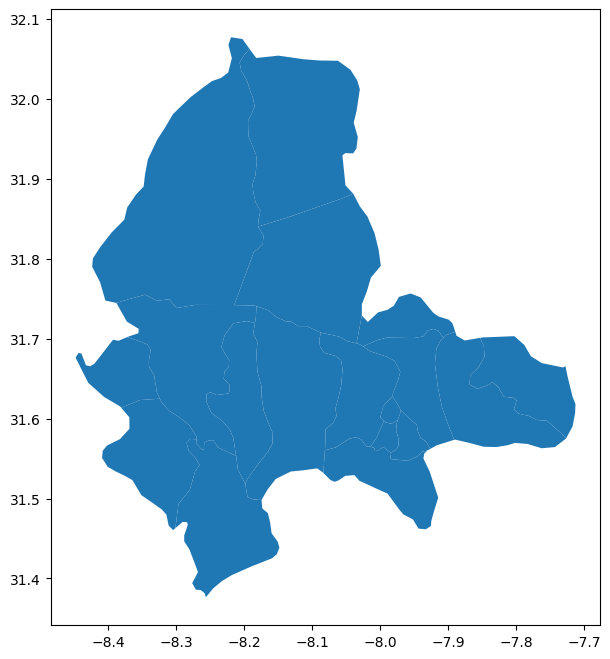

In [68]:
marrakech_districts_gdf.plot(figsize=(8,8))

In [69]:
# Save the filtered districts to a new CSV file
marrakech_districts_gdf.to_csv(f"{OUTPUT_DIR}/Marrakech_Districts.csv", index=False)

# POPULATION USING WORLDPOP

In [73]:
# Defining project paths
BASE_DIR = "D:/Capstone/capstone_repo"
DATA_DIR = f"{BASE_DIR}/data"
RAW_DIR = f"{DATA_DIR}/raw"
PROCESSED_DIR = f"{DATA_DIR}/processed"
DATA_INTERIM = f"{DATA_DIR}/interim"
COLLECTION_OUTPUT_DIR = f"{BASE_DIR}/data/collection_output"

TARGET_CRS = "EPSG:32629"
MAX_ORIGINS = 120_000
AGGREGATION_GRID_M = 200.0

raster_path = f"{RAW_DIR}/worldpop_population.tif"
clipped_raster_path = f"{DATA_INTERIM}/worldpop_clipped.tif"
worldpop_origins_gpkg_path = f"{DATA_INTERIM}/worldpop_origins.gpkg"
worldpop_origins_csv_path = f"{DATA_INTERIM}/worldpop_origins.csv"

import os
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(DATA_INTERIM, exist_ok=True)
os.makedirs(COLLECTION_OUTPUT_DIR, exist_ok=True)


In [74]:
# zonal statistics, and clipping to reduce redundancy.
with rasterio.open(raster_path) as src:
    # Check that the raster has a defined coordinate reference system
    if src.crs is None:
        raise ValueError("WorldPop raster has no CRS")

    # Print key raster properties for verification
    print("Raster CRS:", src.crs)
    print("Raster bounds:", src.bounds)
    print("Raster resolution:", src.res)
    print("Raster nodata:", src.nodata)

    # Reproject district boundaries to the raster CRS for raster-based operations
    districts_raster = marrakech_districts_gdf.to_crs(src.crs) if marrakech_districts_gdf.crs != src.crs else marrakech_districts_gdf.copy()

    # Compute district-level zonal statistics from the population raster
    stats = zonal_stats(
        districts_raster,
        raster_path,
        stats=["sum", "mean", "max"],
        nodata=src.nodata,
        geojson_out=False
    )

    # Add zonal statistics to the district GeoDataFrame
    marrakech_districts_gdf["population_worldpop"] = [s["sum"] for s in stats]
    marrakech_districts_gdf["pop_mean_pixel"] = [s["mean"] for s in stats]
    marrakech_districts_gdf["pop_max_pixel"] = [s["max"] for s in stats]

    # Replace missing values with zero for consistency
    marrakech_districts_gdf["population_worldpop"] = marrakech_districts_gdf["population_worldpop"].fillna(0)
    marrakech_districts_gdf["pop_mean_pixel"] = marrakech_districts_gdf["pop_mean_pixel"].fillna(0)
    marrakech_districts_gdf["pop_max_pixel"] = marrakech_districts_gdf["pop_max_pixel"].fillna(0)

    # Calculate area in square kilometers and population density
    districts_projected = marrakech_districts_gdf.to_crs(TARGET_CRS)  
    marrakech_districts_gdf["area_km2"] = districts_projected.geometry.area / 1_000_000
    marrakech_districts_gdf["pop_density_km2"] = marrakech_districts_gdf["population_worldpop"] / marrakech_districts_gdf["area_km2"]

    # Convert district geometries to GeoJSON-like objects for raster masking
    geoms = [g.__geo_interface__ for g in districts_raster.geometry]

    # Clip the raster to the district study area
    clipped_arr, clipped_transform = mask(
        src,
        geoms,
        crop=True,
        nodata=src.nodata,
        filled=True
    )

    # Extract the first band and convert it to float32
    clipped_band = clipped_arr[0].astype(np.float32)

    # Save useful raster metadata for later use
    raster_nodata = src.nodata
    raster_crs = src.crs

    # Prepare output metadata for writing the clipped raster
    out_meta = src.meta.copy()
    out_meta.update({
        "height": clipped_band.shape[0],
        "width": clipped_band.shape[1],
        "transform": clipped_transform,
        "count": 1,
        "dtype": "float32",
    })

Raster CRS: EPSG:4326
Raster bounds: BoundingBox(left=-13.167916599, bottom=27.669583424, right=-0.9979166480000004, top=35.922916724)
Raster resolution: (0.0008333333299780882, 0.0008333333299676896)
Raster nodata: -99999.0


In [75]:
# Extract valid population data from the clipped raster for origin generation
arr = clipped_band
nodata = raster_nodata
t = clipped_transform
r_crs = raster_crs

# Identify valid raster cells with positive population values
valid = np.isfinite(arr) & (arr > 0)

# Exclude nodata cells when a nodata value is defined
if nodata is not None:
    valid = valid & (arr != nodata)

# Get indices of valid cells
rows, cols = np.where(valid)

# Stop if no populated cells are found
if len(rows) == 0:
    raise ValueError("No valid positive raster cells")

# Extract population values for valid cells
pops = arr[rows, cols].astype(np.float32)

# Compute the center coordinates of valid raster cells
xs, ys = xy(t, rows, cols, offset="center")

In [76]:
# Convert populated raster cells into point-based origins
origins = gpd.GeoDataFrame(
    {
        "origin_id": np.arange(len(pops), dtype=np.int64),
        "population": pops,
    },
    geometry=gpd.points_from_xy(xs, ys),
    crs=r_crs,
).to_crs(TARGET_CRS)

# Store projected coordinates for later distance-based analysis
origins["x"] = origins.geometry.x
origins["y"] = origins.geometry.y

# Reorder columns for clarity
origins = origins[["origin_id", "x", "y", "population", "geometry"]]

print("Number of initial origins:", len(origins))

Number of initial origins: 356147


In [77]:
# Aggregate origins if too many
if len(origins) > MAX_ORIGINS:
    tmp = origins.copy()

    # Assign grid cells
    tmp["gx"] = np.floor(tmp["x"] / AGGREGATION_GRID_M).astype(np.int32)
    tmp["gy"] = np.floor(tmp["y"] / AGGREGATION_GRID_M).astype(np.int32)

    # Aggregate population and coordinates
    ag = tmp.groupby(["gx", "gy"], as_index=False).agg(
        population=("population", "sum"),
        x=("x", "mean"),
        y=("y", "mean")
    )

    # Convert back to GeoDataFrame
    origins = gpd.GeoDataFrame(
        ag,
        geometry=gpd.points_from_xy(ag["x"], ag["y"]),
        crs=TARGET_CRS
    )

    origins = origins.reset_index(drop=True)
    origins["origin_id"] = np.arange(len(origins), dtype=np.int64)

    origins = origins[["origin_id", "x", "y", "population", "geometry"]]

    print("Origins aggregated to:", len(origins))

Origins aggregated to: 65474


In [78]:
# Assign origins to districts
origins = gpd.sjoin(
    origins,
    marrakech_districts_gdf.to_crs(TARGET_CRS),
    how="inner",
    predicate="within"
).drop(columns=["index_right"], errors="ignore")

if origins.empty:
    raise ValueError("No origins assigned to districts")

print("Origins successfully assigned to districts")

Origins successfully assigned to districts


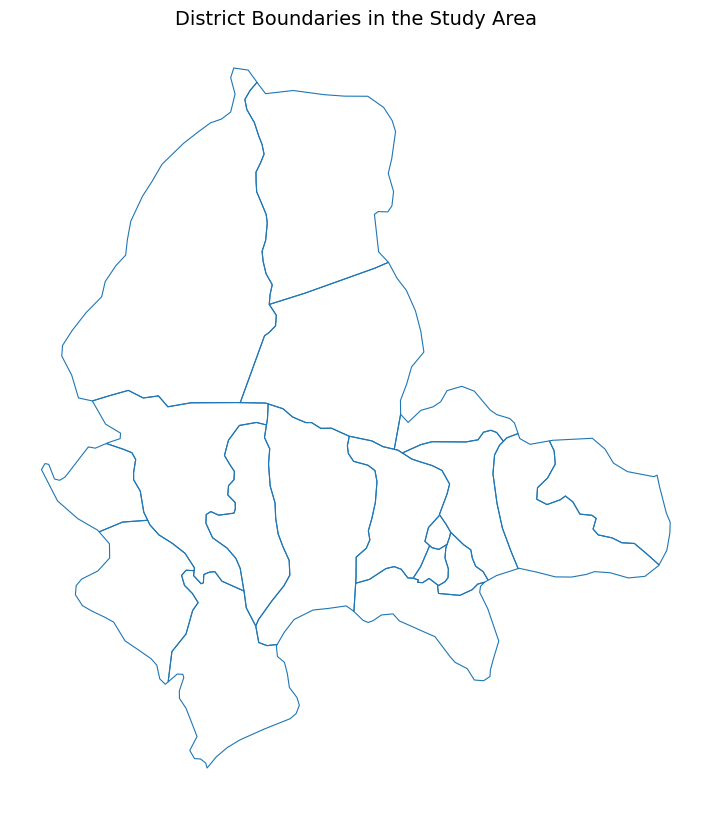

In [79]:
# Reproject districts to the target CRS for consistent plotting
districts_plot = marrakech_districts_gdf.to_crs(TARGET_CRS) if marrakech_districts_gdf.crs != TARGET_CRS else marrakech_districts_gdf.copy()

# Create figure
fig, ax = plt.subplots(figsize=(10, 10))

# Plot district boundaries
districts_plot.boundary.plot(ax=ax, linewidth=0.8)

# Add title
ax.set_title("District Boundaries in the Study Area", fontsize=14)

# Remove axes for cleaner map display
ax.set_axis_off()

plt.show()

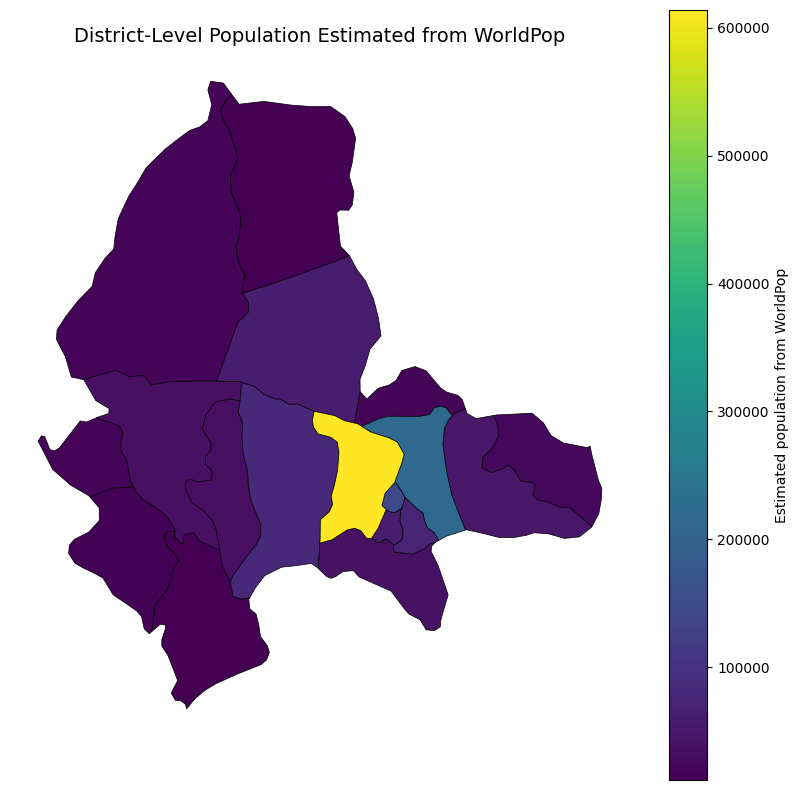

In [80]:
# Create figure
fig, ax = plt.subplots(figsize=(10, 10))

# Plot district population
districts_plot.plot(
    column="population_worldpop",
    ax=ax,
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    legend_kwds={"label": "Estimated population from WorldPop"}
)

# Add title
ax.set_title("District-Level Population Estimated from WorldPop", fontsize=14)

# Remove axes
ax.set_axis_off()

plt.show()

In [81]:
origins.drop(columns="geometry").to_csv(f"{OUTPUT_DIR}/Marrakech_origins.csv", index=False)


# HEALTHCARE

In [82]:
# Define the place to download the street network
place_name = "Marrakesh, Morocco"

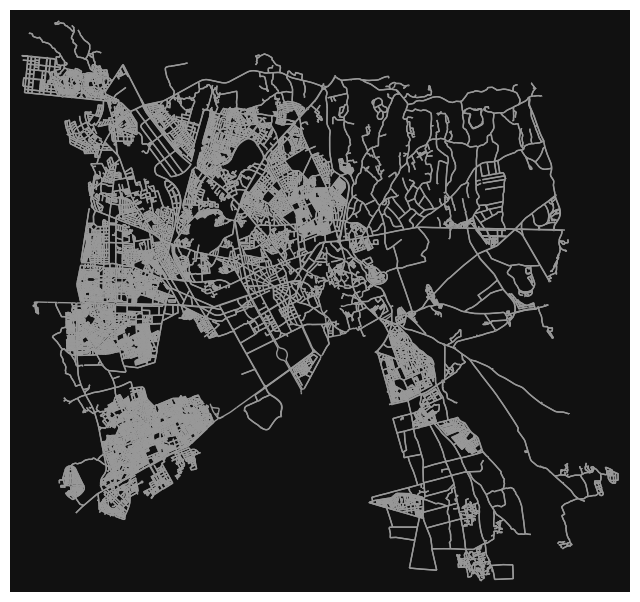

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [83]:
# Download the street network
print(f"Downloading street network for {place_name}...")
G = ox.graph_from_place(place_name, network_type='drive')
ox.plot_graph(G, node_size=0)

In [84]:
# Load the processed district boundaries for Marrakesh, to get healthcare facilities within these boundaries

# Defining tags to filter data for healthcare facilities (hospitals and clinics)
tags = {"amenity": ["hospital", "clinic"]}

# Fetch healthcare facilities within the district boundaries
healthcare= ox.features_from_polygon(marrakech_districts_gdf.unary_union, tags)

healthcare = healthcare[['name', 'amenity', 'geometry']]
healthcare.head()

C:\Users\afafb\AppData\Local\Temp\ipykernel_18740\298495320.py:7: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  healthcare= ox.features_from_polygon(marrakech_districts_gdf.unary_union, tags)


name   amenity                   geometry
element id                                                                    
node    2481427727  Hôpital Riad Al Mokha  hospital  POINT (-7.98802 31.62283)
        2916440455                    NaN    clinic   POINT (-8.00558 31.6317)
        4361734090          الترويض الطبي  hospital  POINT (-8.05727 31.63181)
        4595268265                    NaN    clinic  POINT (-7.99195 31.63144)
        4671702792            مصحة المطار    clinic  POINT (-8.02788 31.59549)

In [87]:
healthcare.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
MultiIndex: 30 entries, ('node', np.int64(2481427727)) to ('way', np.int64(1320549590))
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   name      27 non-null     object  
 1   amenity   30 non-null     object  
 2   geometry  30 non-null     geometry
dtypes: geometry(1), object(2)
memory usage: 2.3+ KB


C:\Users\afafb\AppData\Local\Temp\ipykernel_18740\1004106546.py:33: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='upper right')


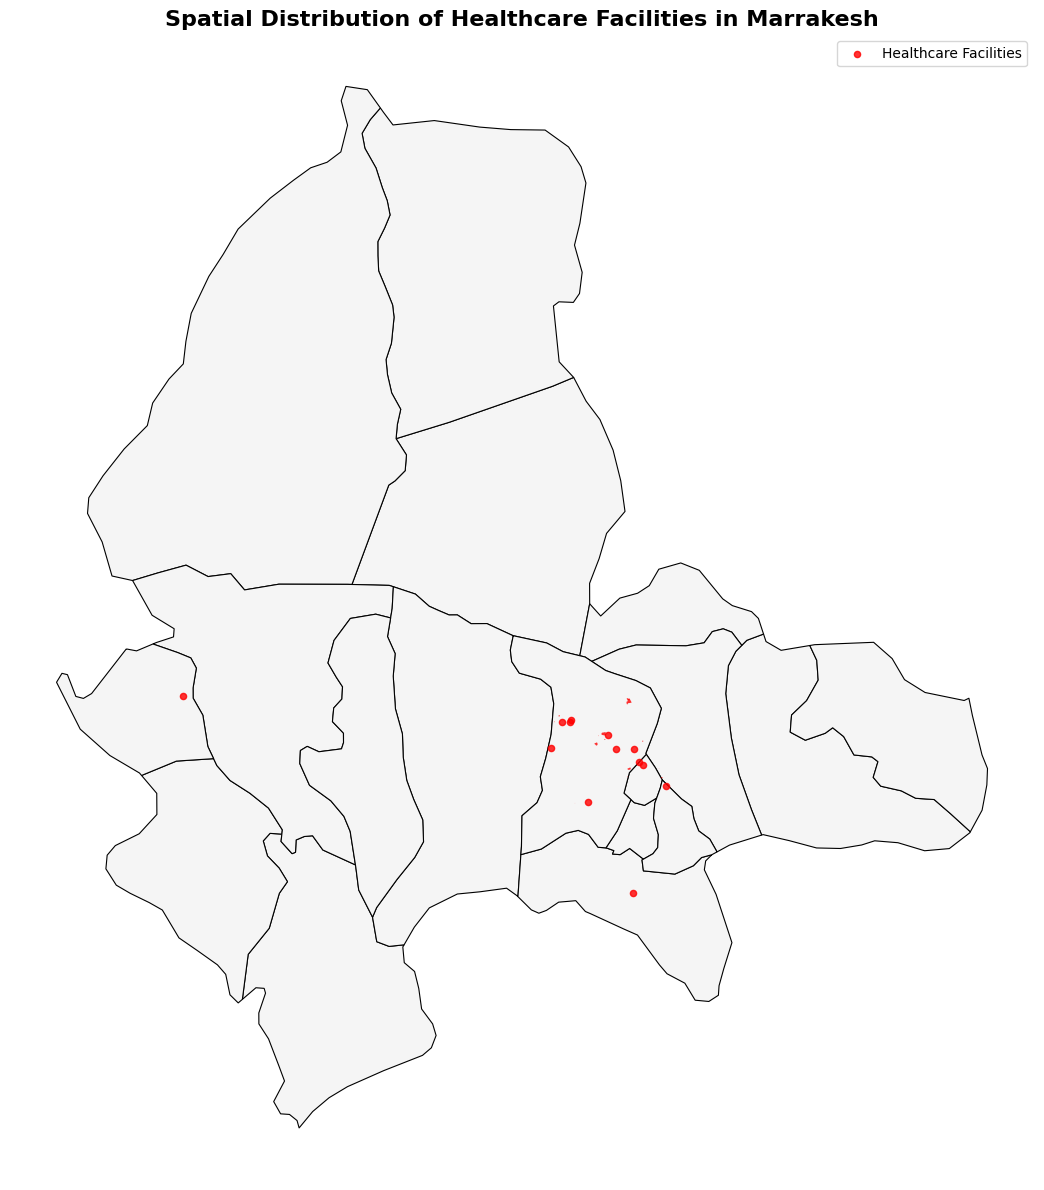

In [86]:
fig, ax = plt.subplots(figsize=(12, 12))

# Plot districts (boundaries)
marrakech_districts_gdf.plot(
    ax=ax,
    edgecolor='black',
    facecolor='#f5f5f5',  # light gray
    linewidth=0.8,
    label='District Boundaries'
)

# Plot healthcare facilities
healthcare.plot(
    ax=ax,
    color='red',
    markersize=20,
    marker='o',
    alpha=0.8,
    label='Healthcare Facilities'
)

# Title
ax.set_title(
    "Spatial Distribution of Healthcare Facilities in Marrakesh",
    fontsize=16,
    fontweight='bold'
)

# Remove axis (clean map look)
ax.set_axis_off()

# Add legend
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig(f'{COLLECTION_OUTPUT_DIR}/HealthcareFacilitiesMap.png', bbox_inches='tight')
plt.show()

In [92]:
healthcare.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
MultiIndex: 30 entries, ('node', np.int64(2481427727)) to ('way', np.int64(1320549590))
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   name      27 non-null     object  
 1   amenity   30 non-null     object  
 2   geometry  30 non-null     geometry
dtypes: geometry(1), object(2)
memory usage: 2.3+ KB


In [95]:
# Make sure coordinates are in lat/lon CRS
healthcare = healthcare.to_crs(epsg=4326)


# Create one point per facility
healthcare["point_geom"] = healthcare.geometry.representative_point()

# Extract lon/lat from that point
healthcare["longitude"] = healthcare["point_geom"].x
healthcare["latitude"] = healthcare["point_geom"].y

In [96]:
healthcare.to_csv(f"{OUTPUT_DIR}/Marrakech_Healthcare.csv")